# Paleta de cores — Presidente 2026 (1º turno)

Preview para aprovação do usuário da paleta definida em `config/candidatos.yaml`
e das funções `mistura_oklab`/`vencedor_margem` de `src/eleicao/cores.py`
(ver `docs/DECISOES.md` D-004).

Conteúdo:
1. Amostra de cor de cada um dos 12 candidatos (nome, hex, % válidos nacional).
2. Gradiente PT↔PL de 0% a 100% (passo 10%), nos dois modos de cor.
3. Mapa das 27 UFs nos dois modos, com os votos reais por UF.
4. Simulação de deuteranopia do mapa (modo mistura).
5. ΔE (OKLab) entre PT e PL — visão normal e simulada — contra o limiar adotado.

A figura final (tudo acima) é exportada em `docs/img/paleta_preview.png`.

In [1]:
import geobr
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import pandas as pd
from coloraide import Color

from eleicao import config as cfg
from eleicao.cores import (
    carregar_paleta,
    distancia_oklab,
    mistura_oklab,
    simular_daltonismo,
    vencedor_margem,
)

plt.rcParams["figure.dpi"] = 110

paleta = carregar_paleta()
df_br = pd.read_parquet(cfg.DATA_PROCESSED / "presidente_t1_br.parquet")
df_uf = pd.read_parquet(cfg.DATA_PROCESSED / "presidente_t1_uf.parquet")

candidatos = df_br.sort_values("votos", ascending=False).reset_index(drop=True)
candidatos[["nr_candidato", "nm_urna", "partido", "votos", "pct_validos"]]

,nr_candidato,nm_urna,partido,votos,pct_validos
0,22,FLAVIO BOLSONARO,PL,56104503,47.027772
1,13,LULA,PT,53879538,45.162768
2,70,ESCRITOR AUGUSTO CURY,AVANTE,3448569,2.890651
3,14,RENAN SANTOS,MISSÃO,2675887,2.242975
4,55,RONALDO CAIADO,PSD,2605148,2.183680
5,30,ZEMA,NOVO,326488,0.273668
6,80,SAMARA,UP,122911,0.103026
7,16,HERTZ DIAS,PSTU,43103,0.036130
8,27,CLARIANA BARAO,DC,40043,0.033565
9,21,EDMILSON COSTA,PCB,22693,0.019022


## 1. Amostra de cor por candidato

C:\Users\Usuário\AppData\Local\Temp\ipykernel_22968\2157959449.py:7: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((0, y), 1, 0.85, color=cor, edgecolor="#00000022"))


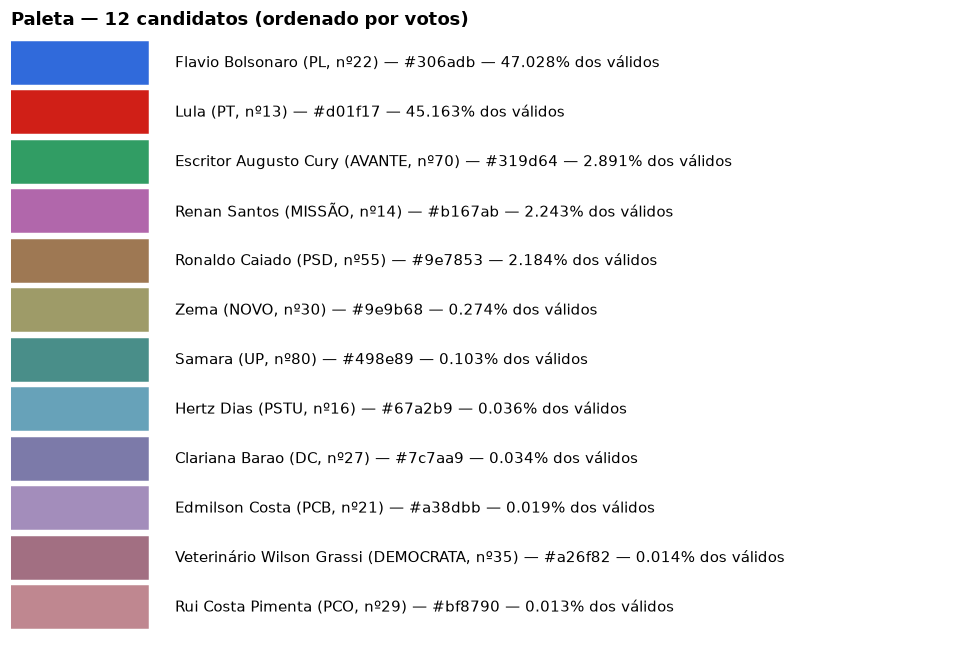

In [2]:
def plotar_swatches(ax, candidatos, paleta, titulo=None):
    n = len(candidatos)
    for i, row in candidatos.iterrows():
        nr = int(row.nr_candidato)
        cor = paleta[nr]
        y = n - 1 - i
        ax.add_patch(plt.Rectangle((0, y), 1, 0.85, color=cor, edgecolor="#00000022"))
        rotulo = (
            f"{row.nm_urna.title()} ({row.partido}, nº{nr}) "
            f"— {cor} — {row.pct_validos:.3f}% dos válidos"
        )
        ax.text(1.2, y + 0.42, rotulo, va="center", fontsize=9.5)
    ax.set_xlim(0, 7)
    ax.set_ylim(-0.2, n)
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, loc="left", fontsize=12, fontweight="bold")


fig, ax = plt.subplots(figsize=(9, 6))
plotar_swatches(ax, candidatos, paleta, "Paleta — 12 candidatos (ordenado por votos)")
fig.tight_layout()
plt.show()

## 2. Gradiente PT ↔ PL (0% a 100%, passo 10%)

`p` = % dos votos (do subconjunto PT+PL) para o PT (nº13); `100-p` para o PL
(nº22). Em `p=0` é 100% PL; em `p=100`, 100% PT — nos dois modos, os extremos
devolvem exatamente a cor de cada um na paleta (ver `tests/test_cores.py`).

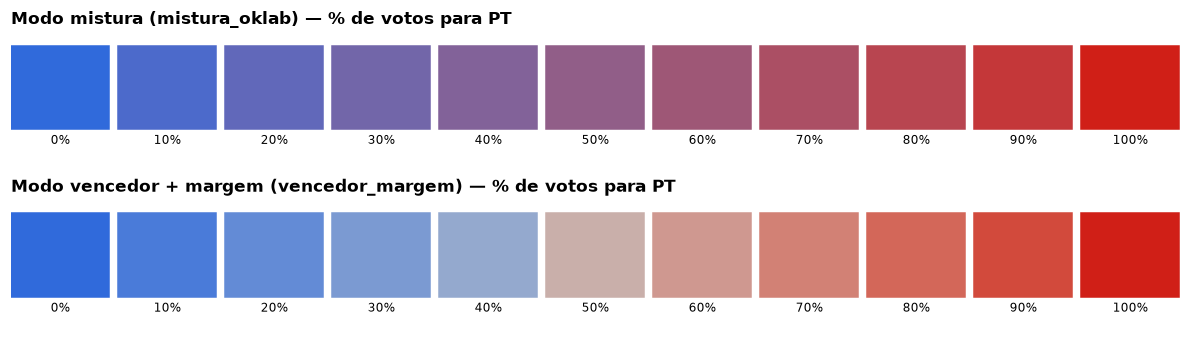

In [3]:
passos = list(range(0, 101, 10))

gradiente_mistura = []
gradiente_vencedor = []
for p in passos:
    votos = {13: p, 22: 100 - p}
    gradiente_mistura.append(mistura_oklab(votos, paleta))
    gradiente_vencedor.append(vencedor_margem(votos, paleta))


def plotar_gradiente(ax, cores, passos, titulo):
    n = len(cores)
    for i, (cor, p) in enumerate(zip(cores, passos, strict=True)):
        ax.add_patch(plt.Rectangle((i, 0), 0.92, 1, color=cor))
        ax.text(i + 0.46, -0.18, f"{p}%", ha="center", fontsize=8)
    ax.set_xlim(0, n)
    ax.set_ylim(-0.4, 1.15)
    ax.axis("off")
    ax.set_title(titulo, loc="left", fontsize=11, fontweight="bold")


titulo_mistura = "Modo mistura (mistura_oklab) — % de votos para PT"
titulo_vencedor = "Modo vencedor + margem (vencedor_margem) — % de votos para PT"

fig, axes = plt.subplots(2, 1, figsize=(11, 3.2))
plotar_gradiente(axes[0], gradiente_mistura, passos, titulo_mistura)
plotar_gradiente(axes[1], gradiente_vencedor, passos, titulo_vencedor)
fig.tight_layout()
plt.show()

## 3. Mapa das 27 UFs — votos reais, dois modos

Usa `presidente_t1_uf.parquet` (exclui `zz`/exterior, que não tem polígono
IBGE) e `geobr.read_state()`.

states_2020_simplified.parquet:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 41.6MB/s]

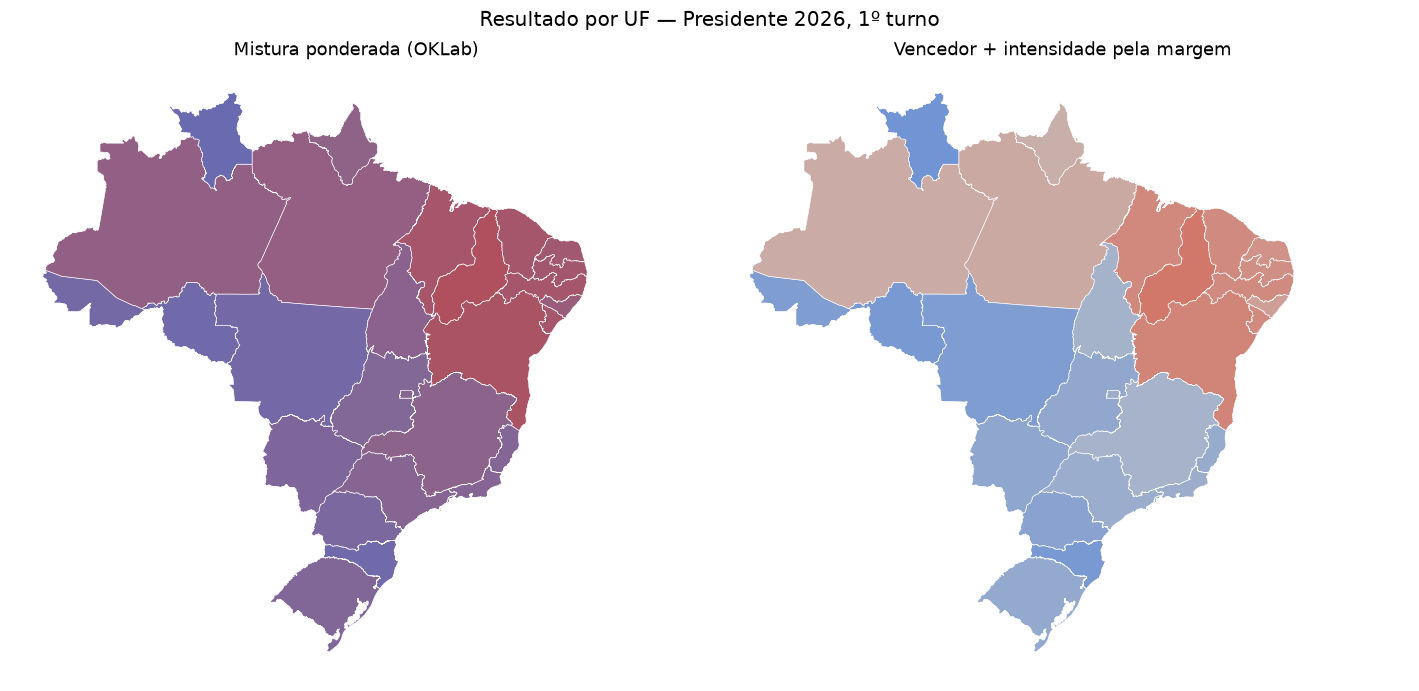

In [4]:
gdf_uf = geobr.read_state(year=2020)
gdf_uf["uf"] = gdf_uf["abbrev_state"].str.lower()

df_uf_validos = df_uf[df_uf["uf"] != "zz"]

cor_mistura_por_uf = {}
cor_vencedor_por_uf = {}
for uf, grupo in df_uf_validos.groupby("uf"):
    votos = dict(zip(grupo["nr_candidato"].astype(int), grupo["votos"].astype(int), strict=True))
    cor_mistura_por_uf[uf] = mistura_oklab(votos, paleta)
    cor_vencedor_por_uf[uf] = vencedor_margem(votos, paleta)

gdf_uf["cor_mistura"] = gdf_uf["uf"].map(cor_mistura_por_uf)
gdf_uf["cor_vencedor"] = gdf_uf["uf"].map(cor_vencedor_por_uf)
assert gdf_uf["cor_mistura"].notna().all() and gdf_uf["cor_vencedor"].notna().all()

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
gdf_uf.plot(ax=axes[0], color=gdf_uf["cor_mistura"], edgecolor="white", linewidth=0.4)
axes[0].set_title("Mistura ponderada (OKLab)", fontsize=12)
axes[0].axis("off")
gdf_uf.plot(ax=axes[1], color=gdf_uf["cor_vencedor"], edgecolor="white", linewidth=0.4)
axes[1].set_title("Vencedor + intensidade pela margem", fontsize=12)
axes[1].axis("off")
fig.suptitle("Resultado por UF — Presidente 2026, 1º turno", fontsize=13)
fig.tight_layout()
plt.show()

## 4. Simulação de deuteranopia — mapa (modo mistura)

Mesma simulação de daltonismo usada para validar PT/PL (seção 5), aplicada
cor a cor no mapa de mistura ponderada.

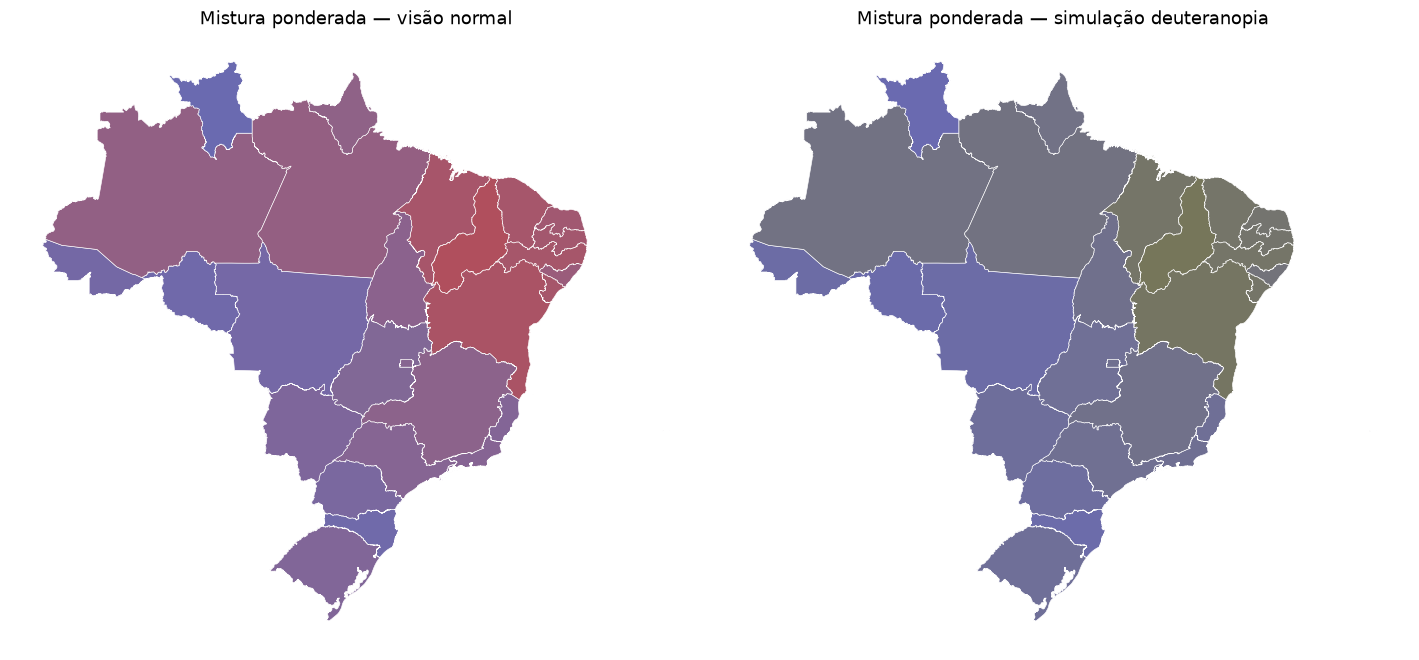

In [5]:
gdf_uf["cor_mistura_deutan"] = gdf_uf["cor_mistura"].apply(
    lambda h: simular_daltonismo(h, "deutan")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
gdf_uf.plot(ax=axes[0], color=gdf_uf["cor_mistura"], edgecolor="white", linewidth=0.4)
axes[0].set_title("Mistura ponderada — visão normal", fontsize=12)
axes[0].axis("off")
gdf_uf.plot(ax=axes[1], color=gdf_uf["cor_mistura_deutan"], edgecolor="white", linewidth=0.4)
axes[1].set_title("Mistura ponderada — simulação deuteranopia", fontsize=12)
axes[1].axis("off")
fig.tight_layout()
plt.show()

## 5. ΔE (OKLab) entre PT e PL — visão normal e simulada

Distância perceptual calculada com `distancia_oklab` (método `"ok"` do
`coloraide`, baseado em OKLab). Limiar adotado: **ΔE ≥ 0,10** é considerado
"facilmente distinguível" — valor consistente com a recomendação da skill
`dataviz` do projeto (`scripts/validate_palette.js`), que usa a mesma métrica
numa escala ×100 e pede ΔE ≥ 8 (= 0,08 nesta escala) entre pares adjacentes
sob simulação de CVD, e ΔE ≥ 15 (= 0,15) em visão normal.

In [6]:
pt_hex, pl_hex = paleta[13], paleta[22]
l_pt = Color(pt_hex).convert("oklab")[0]
l_pl = Color(pl_hex).convert("oklab")[0]

pt_protan = simular_daltonismo(pt_hex, "protan")
pl_protan = simular_daltonismo(pl_hex, "protan")
pt_deutan = simular_daltonismo(pt_hex, "deutan")
pl_deutan = simular_daltonismo(pl_hex, "deutan")

de_normal = distancia_oklab(pt_hex, pl_hex)
de_protan = distancia_oklab(pt_protan, pl_protan)
de_deutan = distancia_oklab(pt_deutan, pl_deutan)

metricas = [
    "ΔL (OKLab)",
    "ΔE visão normal",
    "ΔE simulação protanopia",
    "ΔE simulação deuteranopia",
]
resumo = pd.DataFrame(
    {
        "métrica": metricas,
        "valor": [abs(l_pt - l_pl), de_normal, de_protan, de_deutan],
        "limiar": ["< 0.05", "≥ 0.10", "≥ 0.10", "≥ 0.10"],
        "passa?": [
            abs(l_pt - l_pl) < 0.05,
            de_normal >= 0.10,
            de_protan >= 0.10,
            de_deutan >= 0.10,
        ],
    }
)
resumo

,métrica,valor,limiar,passa?
0,ΔL (OKLab),0.000844,< 0.05,True
1,ΔE visão normal,0.352614,≥ 0.10,True
2,ΔE simulação protanopia,0.289212,≥ 0.10,True
3,ΔE simulação deuteranopia,0.308806,≥ 0.10,True


## 6. Figura final (exportada em `docs/img/paleta_preview.png`)

Combina os 5 elementos acima em uma única imagem.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_22968\2157959449.py:7: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((0, y), 1, 0.85, color=cor, edgecolor="#00000022"))


Salvo em C:\Users\Usuário\Pessoal\analise_eleicao_2026\docs\img\paleta_preview.png


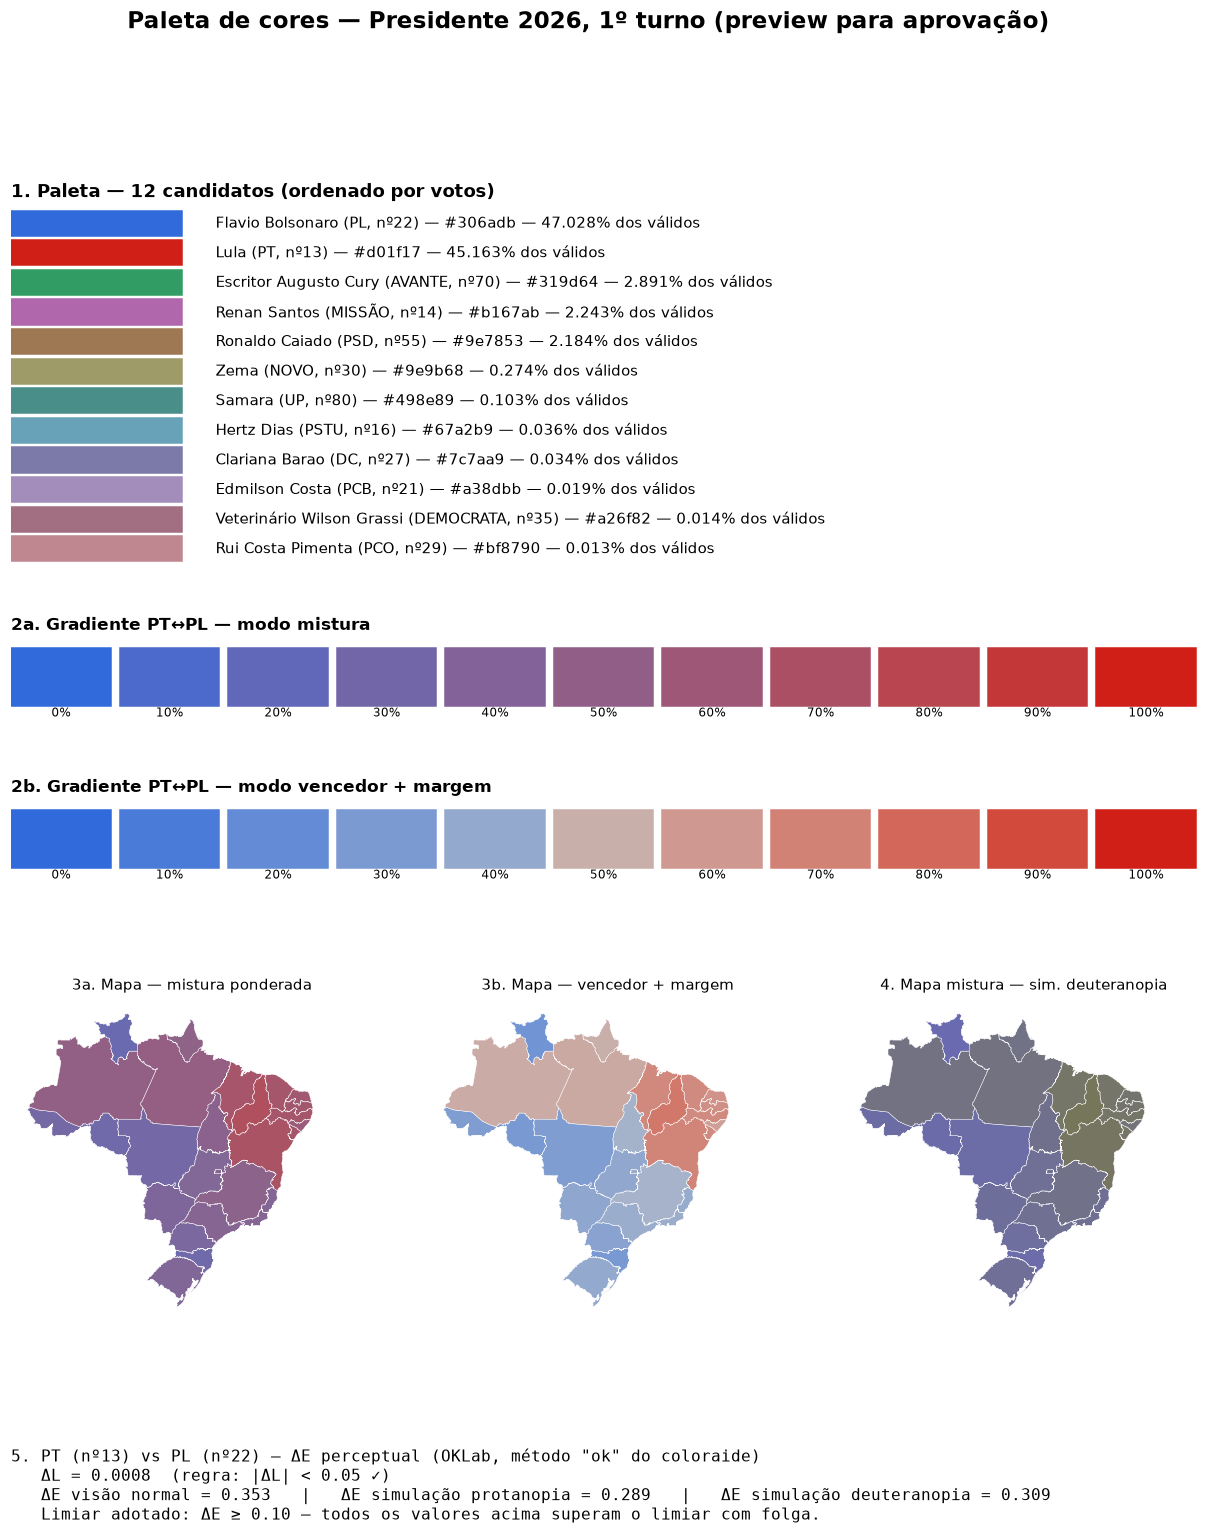

In [7]:
fig = plt.figure(figsize=(14, 15.5))
gs = gridspec.GridSpec(5, 3, height_ratios=[2.2, 0.55, 0.55, 2.4, 0.55], hspace=0.35, wspace=0.15)

ax_swatches = fig.add_subplot(gs[0, :])
plotar_swatches(ax_swatches, candidatos, paleta, "1. Paleta — 12 candidatos (ordenado por votos)")

ax_grad1 = fig.add_subplot(gs[1, :])
plotar_gradiente(ax_grad1, gradiente_mistura, passos, "2a. Gradiente PT↔PL — modo mistura")

ax_grad2 = fig.add_subplot(gs[2, :])
titulo_grad2_fig = "2b. Gradiente PT↔PL — modo vencedor + margem"
plotar_gradiente(ax_grad2, gradiente_vencedor, passos, titulo_grad2_fig)

ax_m1 = fig.add_subplot(gs[3, 0])
gdf_uf.plot(ax=ax_m1, color=gdf_uf["cor_mistura"], edgecolor="white", linewidth=0.3)
ax_m1.set_title("3a. Mapa — mistura ponderada", fontsize=10)
ax_m1.axis("off")

ax_m2 = fig.add_subplot(gs[3, 1])
gdf_uf.plot(ax=ax_m2, color=gdf_uf["cor_vencedor"], edgecolor="white", linewidth=0.3)
ax_m2.set_title("3b. Mapa — vencedor + margem", fontsize=10)
ax_m2.axis("off")

ax_m3 = fig.add_subplot(gs[3, 2])
gdf_uf.plot(ax=ax_m3, color=gdf_uf["cor_mistura_deutan"], edgecolor="white", linewidth=0.3)
ax_m3.set_title("4. Mapa mistura — sim. deuteranopia", fontsize=10)
ax_m3.axis("off")

ax_texto = fig.add_subplot(gs[4, :])
ax_texto.axis("off")
linha_de = (
    f"   ΔE visão normal = {de_normal:.3f}   |   "
    f"ΔE simulação protanopia = {de_protan:.3f}   |   "
    f"ΔE simulação deuteranopia = {de_deutan:.3f}"
)
linhas = [
    '5. PT (nº13) vs PL (nº22) — ΔE perceptual (OKLab, método "ok" do coloraide)',
    f"   ΔL = {abs(l_pt - l_pl):.4f}  (regra: |ΔL| < 0.05 ✓)",
    linha_de,
    "   Limiar adotado: ΔE ≥ 0.10 — todos os valores acima superam o limiar com folga.",
]
ax_texto.text(0, 0.8, "\n".join(linhas), fontsize=10.5, va="top", family="monospace")

fig.suptitle(
    "Paleta de cores — Presidente 2026, 1º turno (preview para aprovação)",
    fontsize=15,
    fontweight="bold",
    y=0.995,
)

caminho_png = cfg.RAIZ / "docs" / "img" / "paleta_preview.png"
caminho_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(caminho_png, dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo em {caminho_png}")
plt.show()